# Section flow
1. Import Libraries

2. Baseline Model
   Logistic Regression

3. Decision Tree

4. Random Forest ⭐

5. Model Evaluation

6. Classification Report

7. Confusion Matrix

8. ROC Curve

9. Feature Importance

10. Model Comparison Table

11. Select Best Model

12. Save Model (.pkl)

13. Save Preprocessor (.pkl)

14. Final Conclusion

# Customer Churn Prediction - Model Building

## Objective

The objective of this notebook is to train and evaluate multiple machine learning classification models for customer churn prediction.

The performance of different algorithms will be compared using standard evaluation metrics, and the best-performing model will be selected for deployment.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")

### Observation

The required libraries for model training and evaluation have been imported successfully.

These libraries provide machine learning algorithms, evaluation metrics, and visualization tools.
### Business Insight

Different machine learning algorithms capture customer behavior differently.

Comparing multiple models helps identify the most reliable approach for predicting customer churn.

In [2]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split

In [11]:
import joblib

X_train_processed = joblib.load("../models/X_train_processed.pkl")
X_test_processed = joblib.load("../models/X_test_processed.pkl")

y_train = joblib.load("../models/y_train.pkl")
y_test = joblib.load("../models/y_test.pkl")

In [12]:
print("Training Data :", X_train_processed.shape)
print("Testing Data  :", X_test_processed.shape)
print("Training Labels:", y_train.shape)
print("Testing Labels :", y_test.shape)

Training Data : (5634, 1178)
Testing Data  : (1409, 1178)
Training Labels: (5634,)
Testing Labels : (1409,)


In [ ]:
df = df.drop(
    columns=[
        "CustomerID",
        "Count",
        "Country",
        "State",
        "Churn Value",
        "Churn Score",
        "Churn Reason",
        "Lat Long"
    ]
)

In [5]:
df["Total Charges"] = pd.to_numeric(
    df["Total Charges"].replace(" ", 0)
)

In [6]:
X = df.drop("Churn Label", axis=1)

y = df["Churn Label"].map({
    "No":0,
    "Yes":1
})

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
preprocessor = joblib.load("../models/preprocessor.pkl")

In [9]:
X_train_processed = preprocessor.transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [10]:
print(X_train_processed.shape)
print(X_test_processed.shape)

(5634, 1178)
(1409, 1178)


### Logistic Regression

Logistic Regression is used as a baseline classification model for predicting whether a customer is likely to churn.

It is simple, interpretable, and provides a strong baseline for comparing the performance of other classification algorithms.

In [13]:
from sklearn.linear_model import LogisticRegression

# Initialize Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
logistic_model.fit(X_train_processed, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [14]:
# Make predictions on the test data
y_pred_logistic = logistic_model.predict(X_test_processed)

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred_logistic))

Predictions generated successfully.
Number of predictions: 1409


## Logistic Regression Evaluation

The trained model is evaluated on the unseen testing dataset using standard classification metrics.

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred_logistic)
precision = precision_score(y_test, y_pred_logistic)
recall = recall_score(y_test, y_pred_logistic)
f1 = f1_score(y_test, y_pred_logistic)

print("Logistic Regression Performance")
print("--------------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Logistic Regression Performance
--------------------------------
Accuracy : 0.7921
Precision: 0.6216
Recall   : 0.5535
F1 Score : 0.5856


## Decision Tree Classifier

Decision Tree is a tree-based classification algorithm that learns decision rules from the training data.

It is useful for identifying non-linear relationships and provides an interpretable model for customer churn prediction.

In [16]:
from sklearn.tree import DecisionTreeClassifier

# Initialize Decision Tree model
decision_tree_model = DecisionTreeClassifier(
    max_depth=6,
    random_state=42
)

# Train the model
decision_tree_model.fit(X_train_processed, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [17]:
# Make predictions on the test data
y_pred_tree = decision_tree_model.predict(X_test_processed)

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred_tree))

Predictions generated successfully.
Number of predictions: 1409


## Decision Tree Evaluation

The Decision Tree model is evaluated on the unseen testing dataset using accuracy, precision, recall, and F1 score.

In [18]:
accuracy_tree = accuracy_score(y_test, y_pred_tree)
precision_tree = precision_score(y_test, y_pred_tree)
recall_tree = recall_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)

print("Decision Tree Performance")
print("-------------------------")
print(f"Accuracy : {accuracy_tree:.4f}")
print(f"Precision: {precision_tree:.4f}")
print(f"Recall   : {recall_tree:.4f}")
print(f"F1 Score : {f1_tree:.4f}")

Decision Tree Performance
-------------------------
Accuracy : 0.7828
Precision: 0.5914
Recall   : 0.5882
F1 Score : 0.5898


## Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction stability and generalization.

It is suitable for customer churn prediction because it can capture complex relationships between customer characteristics and churn behavior.

In [19]:
from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest model
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

# Train the model
random_forest_model.fit(X_train_processed, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [20]:
# Make predictions on the test data
y_pred_rf = random_forest_model.predict(X_test_processed)

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred_rf))

Predictions generated successfully.
Number of predictions: 1409


## Random Forest Evaluation

The Random Forest model is evaluated on the unseen testing dataset using accuracy, precision, recall, and F1 score.

In [21]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("-------------------------")
print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1 Score : {f1_rf:.4f}")

Random Forest Performance
-------------------------
Accuracy : 0.7942
Precision: 0.7143
Recall   : 0.3743
F1 Score : 0.4912


## Model Performance Comparison

The performance of the trained classification models is compared using accuracy, precision, recall, and F1 score.

Comparing multiple metrics provides a better understanding of model performance, especially when the target classes may be imbalanced.

In [22]:
# Create model performance comparison table

model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        accuracy_tree,
        accuracy_rf
    ],
    "Precision": [
        precision,
        precision_tree,
        precision_rf
    ],
    "Recall": [
        recall,
        recall_tree,
        recall_rf
    ],
    "F1 Score": [
        f1,
        f1_tree,
        f1_rf
    ]
})

model_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.792051,0.621622,0.553476,0.585573
1,Decision Tree,0.782825,0.591398,0.588235,0.589812
2,Random Forest,0.794180,0.714286,0.374332,0.491228


In [23]:
# Round the performance metrics for better readability

model_results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.7921,0.6216,0.5535,0.5856
1,Decision Tree,0.7828,0.5914,0.5882,0.5898
2,Random Forest,0.7942,0.7143,0.3743,0.4912


## Model Selection

For customer churn prediction, F1 score is considered an important metric because it balances precision and recall.

The model with the highest F1 score provides a better balance between identifying churn customers and avoiding incorrect predictions.

In [24]:
best_model_row = model_results.loc[
    model_results["F1 Score"].idxmax()
]

print("Best Model based on F1 Score:")
print(best_model_row)

Best Model based on F1 Score:
Model        Decision Tree
Accuracy          0.782825
Precision         0.591398
Recall            0.588235
F1 Score          0.589812
Name: 1, dtype: object


## Confusion Matrix

A confusion matrix provides a detailed view of the classification results by comparing actual customer churn labels with the predicted labels.

It helps identify correct predictions as well as false positives and false negatives.

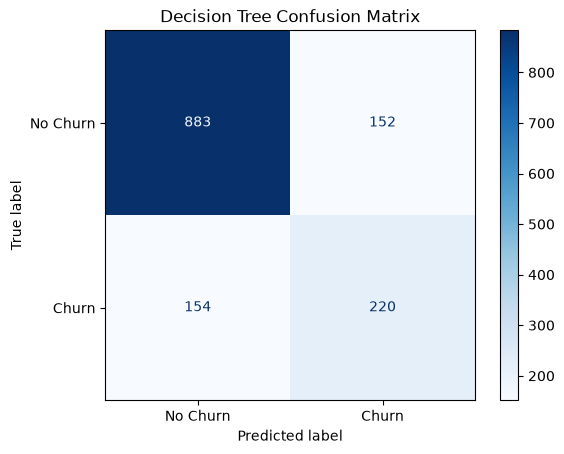

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate confusion matrix for the Decision Tree model
cm = confusion_matrix(y_test, y_pred_tree)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot(cmap="Blues")
plt.title("Decision Tree Confusion Matrix")
plt.show()

### Confusion Matrix Interpretation

The confusion matrix shows four types of predictions:

- True Negative (TN): Customers correctly predicted as not churning.
- False Positive (FP): Customers incorrectly predicted as churning.
- False Negative (FN): Churning customers incorrectly predicted as not churning.
- True Positive (TP): Customers correctly predicted as churning.

For customer churn prediction, reducing false negatives is particularly important because missed churners may result in lost customers.

In [26]:
tn, fp, fn, tp = cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

True Negatives : 883
False Positives: 152
False Negatives: 154
True Positives : 220


## Classification Report

The classification report provides precision, recall, F1 score, and support for each churn class.

It gives a detailed evaluation of how well the model identifies both churn and non-churn customers.

In [27]:
from sklearn.metrics import classification_report

print("Decision Tree Classification Report")
print("------------------------------------")

print(
    classification_report(
        y_test,
        y_pred_tree,
        target_names=["No Churn", "Churn"]
    )
)

Decision Tree Classification Report
------------------------------------
              precision    recall  f1-score   support

    No Churn       0.85      0.85      0.85      1035
       Churn       0.59      0.59      0.59       374

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409



### Classification Report Observation

The classification report provides a class-wise evaluation of the Decision Tree model.

The recall for the Churn class is particularly important because it indicates how effectively the model identifies customers who actually churn.

## ROC-AUC Evaluation

The ROC curve evaluates the ability of the Decision Tree model to distinguish between churn and non-churn customers across different classification thresholds.

The Area Under the Curve (AUC) summarizes the overall discriminatory performance of the model.

Decision Tree ROC-AUC Score: 0.8284


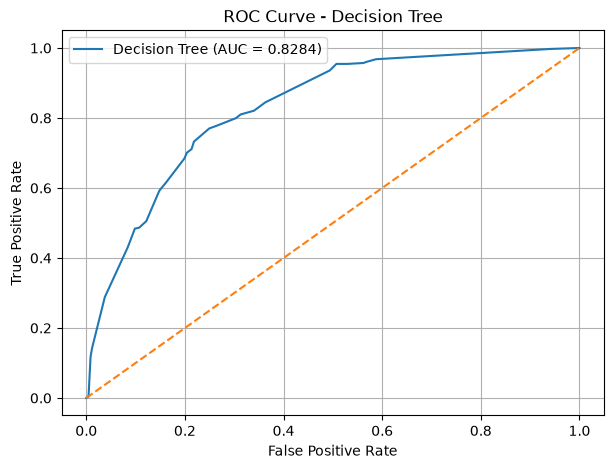

In [28]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probability of the positive class (Churn)
y_prob_tree = decision_tree_model.predict_proba(X_test_processed)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_tree)

# Calculate AUC
auc_score = roc_auc_score(y_test, y_prob_tree)

print(f"Decision Tree ROC-AUC Score: {auc_score:.4f}")

# Plot ROC curve
plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, label=f"Decision Tree (AUC = {auc_score:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.grid()

plt.show()

### ROC-AUC Observation

The ROC-AUC score indicates how effectively the Decision Tree model distinguishes between churn and non-churn customers.

A higher AUC value indicates better class-separation capability. The ROC curve also shows the trade-off between the true positive rate and false positive rate at different classification thresholds.

## Feature Importance Analysis

Feature importance is used to identify which features contribute most to the Decision Tree's churn predictions.

Understanding important features helps translate the machine learning results into actionable business insights.

In [29]:
# Get feature importance from the trained Decision Tree
feature_importance = decision_tree_model.feature_importances_

# Get feature names from the preprocessing pipeline
feature_names = preprocessor.get_feature_names_out()

# Create a DataFrame
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance
})

# Sort features by importance
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Display top 15 features
importance_df.head(15)

,Feature,Importance
1169,cat__Contract_Month-to-month,0.438692
1149,cat__Internet Service_Fiber optic,0.139349
3,num__Tenure Months,0.137011
1141,cat__Dependents_No,0.061586
5,num__Total Charges,0.038456
4,num__Monthly Charges,0.035428
1176,cat__Payment Method_Electronic check,0.020612
1160,cat__Tech Support_No,0.018246
0,num__Zip Code,0.016587
6,num__CLTV,0.013630


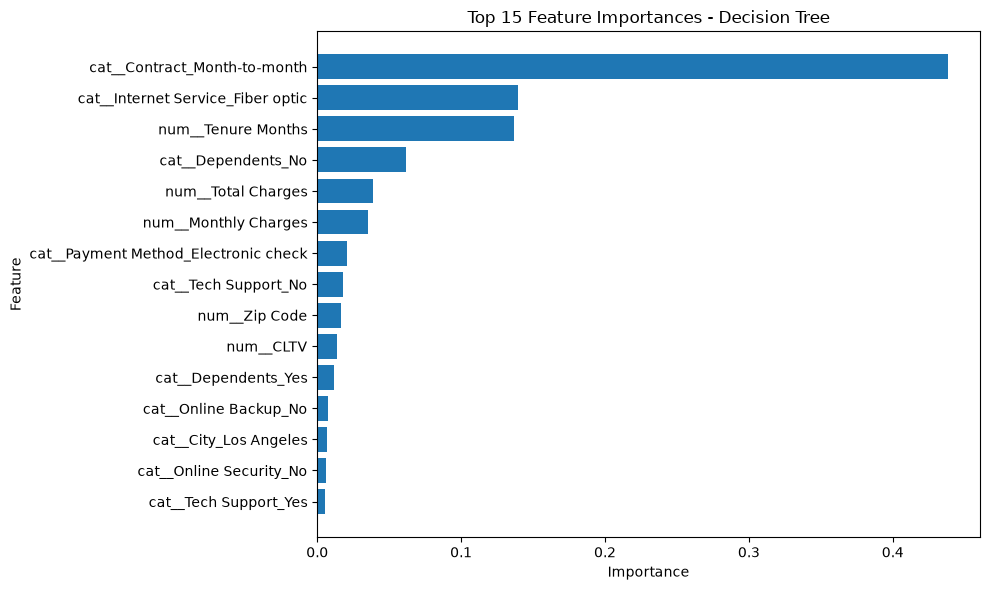

In [30]:
plt.figure(figsize=(10, 6))

top_features = importance_df.head(15).sort_values(
    by="Importance"
)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Decision Tree")

plt.tight_layout()
plt.show()

### Feature Importance Observation

The feature importance analysis identifies the customer attributes that contribute most to the Decision Tree's churn predictions.

The most important features can be used to understand customer behavior and identify potential factors associated with customer churn.

## Business Insights

The feature importance analysis provides several useful insights into customer churn behavior.

- Month-to-month contracts are the most influential feature in churn prediction, indicating that customers without long-term commitments may be more likely to churn.
- Fiber optic internet service is another important factor associated with churn behavior.
- Tenure is also highly influential, suggesting that customer relationship duration plays an important role in churn prediction.
- Dependents, total charges, and monthly charges also contribute to the model's predictions.
- Electronic check payment method and lack of technical support show additional influence on churn behavior.

These insights can help the business focus retention strategies on customers with month-to-month contracts, shorter tenure, higher monthly charges, and specific service or payment characteristics.

## Model Selection Summary

Among the evaluated models, the Decision Tree achieved the highest F1 score of 0.5898.

Since customer churn prediction requires a balance between precision and recall, the Decision Tree is selected as the final model for this project.

The selected model will be saved and used for future customer churn predictions.

In [31]:
# Save the selected Decision Tree model

import joblib

joblib.dump(
    decision_tree_model,
    "../models/decision_tree_model.pkl"
)

print("Final Decision Tree model saved successfully.")

Final Decision Tree model saved successfully.


In [32]:
# Verify that the saved model can be loaded successfully

loaded_model = joblib.load(
    "../models/decision_tree_model.pkl"
)

print("Saved model loaded successfully.")
print("Model type:", type(loaded_model))

Saved model loaded successfully.
Model type: <class 'sklearn.tree._classes.DecisionTreeClassifier'>


## Final Model Validation

The saved Decision Tree model is loaded again and tested on the unseen test dataset.

This final validation confirms that the saved model can generate predictions correctly after being reloaded.

In [33]:
# Generate predictions using the reloaded model

y_pred_final = loaded_model.predict(X_test_processed)

print("Final model prediction completed successfully.")
print("Number of predictions:", len(y_pred_final))

Final model prediction completed successfully.
Number of predictions: 1409


In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

final_accuracy = accuracy_score(y_test, y_pred_final)
final_precision = precision_score(y_test, y_pred_final)
final_recall = recall_score(y_test, y_pred_final)
final_f1 = f1_score(y_test, y_pred_final)

print("Final Decision Tree Performance")
print("--------------------------------")
print(f"Accuracy  : {final_accuracy:.4f}")
print(f"Precision : {final_precision:.4f}")
print(f"Recall    : {final_recall:.4f}")
print(f"F1 Score  : {final_f1:.4f}")

Final Decision Tree Performance
--------------------------------
Accuracy  : 0.7828
Precision : 0.5914
Recall    : 0.5882
F1 Score  : 0.5898


# Conclusion

This project developed a machine learning based customer churn prediction system.

The workflow included:

1. Data understanding and exploration
2. Exploratory Data Analysis
3. Data cleaning and preprocessing
4. Feature encoding and transformation
5. Training multiple classification models
6. Model evaluation using accuracy, precision, recall, and F1 score
7. Confusion matrix and ROC-AUC analysis
8. Feature importance analysis
9. Model comparison and selection
10. Saving and validating the final Decision Tree model

Among the evaluated models, the Decision Tree achieved the highest F1 score of 0.5898 and was selected as the final model.

The feature importance analysis showed that month-to-month contracts, fiber optic internet service, and customer tenure were among the most influential factors in churn prediction.

The final trained model has been saved as a reusable `.pkl` file for deployment and future predictions.

# Conclusion

This project developed a machine learning based customer churn prediction system using customer demographic, service, contract, and billing information.

The complete workflow included data understanding, exploratory data analysis, data cleaning, preprocessing, feature encoding, model training, model evaluation, and feature importance analysis.

Three classification models were evaluated: Logistic Regression, Decision Tree, and Random Forest. Based on the F1 score, the Decision Tree achieved the best overall balance between precision and recall with an F1 score of 0.5898.

The Decision Tree also achieved an ROC-AUC score of 0.8284, indicating good capability to distinguish between churn and non-churn customers.

Feature importance analysis showed that month-to-month contracts, fiber optic internet service, customer tenure, dependents, and billing-related features were among the most influential factors in churn prediction.

The final Decision Tree model was saved as a reusable `.pkl` file and successfully reloaded and validated on the unseen test dataset.

This model can serve as a foundation for a customer retention system that helps businesses identify customers who may be at higher risk of churn.